# Logistic Regression on an Environmental Microbial Dataset

**Project:** Logistic Regression on an Environmental Microbial Dataset  
**Research Question:** Can a logistic regression model be constructed on the environmental dataset?  
**Null Hypothesis:** A logistic regression model cannot be constructed on the environmental dataset.  
**Alternative Hypothesis:** A logistic regression model can be constructed on the environmental dataset at an accuracy greater than 70%.

Elevated environmental-monitoring results can indicate where preventive attention is most valuable. The business purpose of this analysis is to determine whether information available before a sample result—such as its planned location, sampling program, and season—can help prioritize monitoring, cleaning, and preventive action. Logistic regression is the primary model; balanced logistic regression and Random Forest are included only to clarify the tradeoffs created by the rare positive class.


### Imports and reproducibility

The analysis uses a fixed random seed of 42


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

RANDOM_STATE = 42

### Loading the cleaned modeling dataset

In [2]:
df = pd.read_csv("environmental_monitoring_microbiology_2022_2026.csv")
print(df.shape)
df.head()


(10531, 18)


,Mid,DepartmentName,AreaName,SiteName,Location,Alert,Action,SampleDate,CFU,Zone,Frequency,Action/Alert Count,Air_AirUnits.AirType,Year,Month,MonthName,DayOfYear,Season
0,46243,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,6.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
1,46272,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,8.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
2,46287,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,8.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
3,46331,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,11.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer
4,46332,Filling and Assembly,WC 5 - East,R30,Staging,30.0,40.0,2023-08-09,15.0,Clean,Monthly,NaN,(CFU/160L),2023,8,August,221,Summer


### Validate the cleaned dataset

These checks verify the cleaned data.


In [5]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

df.head()

df["SampleDate"] = pd.to_datetime(df["SampleDate"])

print("Date range:")
print(df["SampleDate"].min(), "to", df["SampleDate"].max())

categorical_columns = [
    "DepartmentName",
    "AreaName",
    "SiteName",
    "Location",
    "Zone",
    "Frequency",
    "Air_AirUnits.AirType",
    "Season"
]

print("\nUnique values:")
print(df[categorical_columns].nunique())

Dataset shape: (10531, 18)
Duplicate rows: 0

Missing values:
Mid                         0
DepartmentName              0
AreaName                    0
SiteName                    0
Location                    0
Alert                     794
Action                    794
SampleDate                  0
CFU                         0
Zone                        0
Frequency                   0
Action/Alert Count      10172
Air_AirUnits.AirType        0
Year                        0
Month                       0
MonthName                   0
DayOfYear                   0
Season                      0
dtype: int64

Data types:
Mid                              int64
DepartmentName                     str
AreaName                           str
SiteName                           str
Location                           str
Alert                          float64
Action                         float64
SampleDate              datetime64[us]
CFU                            float64
Zone                 

## Date and seasonality

The sample date is known when sampling is planned. It is parsed and used to derive month, year, and season. 

Seasons are defined as Winter (December–February), Spring (March–May), Summer (June–August), and Fall (September–November).


In [45]:
print(df[["SampleDate", "Year", "Month", "Season"]].dtypes)
df[["SampleDate", "Year", "Month", "Season"]].head()

# bringing Site and Location together to create a new column called Site_Location
df["Site_Location"] = (df["SiteName"].astype(str) + " - " +df["Location"].astype(str))

SampleDate    datetime64[us]
Year                   int64
Month                  int64
Season                   str
dtype: object


## 5. Create the binary target

`Elevated_Result` is derived only from the recorded `Action/Alert Count` field:

- blank/acceptable → 0
- Alert → 1
- Action → 1

Unexpected labels trigger an error rather than being silently assigned to a class.


In [14]:
df["Elevated_Result"] = (df["Action/Alert Count"].isin(["Alert", "Action"]).astype(int))

print(df["Elevated_Result"].value_counts())
print(df["Elevated_Result"].value_counts(normalize=True) * 100)

Elevated_Result
0    10172
1      359
Name: count, dtype: int64
Elevated_Result
0    96.591017
1     3.408983
Name: proportion, dtype: float64


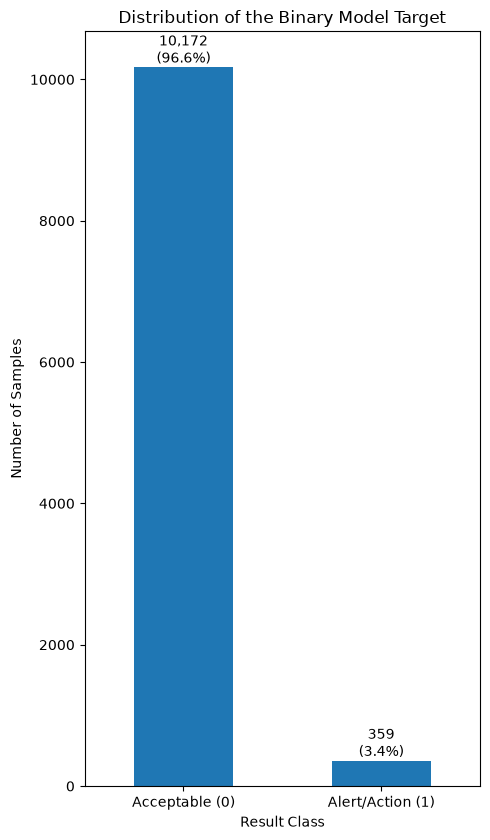

In [44]:
class_summary = df["Elevated_Result"].value_counts().sort_index()
class_percent = df["Elevated_Result"].value_counts(normalize=True).sort_index() * 100

ax = class_summary.plot(
    kind="bar",
    figsize=(5, 8.5)
)

plt.title("Distribution of the Binary Model Target")
plt.xlabel("Result Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Acceptable (0)", "Alert/Action (1)"], rotation=0)

for i, value in enumerate(class_summary):
    plt.text(
        i,
        value,
        f"{value:,}\n({class_percent.iloc[i]:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 6. Predictor selection and leakage prevention

Only fields reasonably known before the microbial result is available are predictors. `CFU`, the alert/action thresholds, and the target-defining result field are explicitly excluded because they either reveal the observed result or directly determine its classification. `Mid` is an identifier, while raw or redundant date fields are excluded for parsimony.

The Department → Area → Site → location hierarchy is retained because it represents planned sampling context. Its correlation and sparse categories are addressed later as limitations.


In [46]:
features = [
    "DepartmentName",
    "AreaName",
    "Site_Location",
    "Zone",
    "Frequency",
    "Air_AirUnits.AirType",
    "Year",
    "Season"
]

leakage_columns = [
    "CFU",
    "Alert",
    "Action",
    "Action/Alert Count"
]

excluded_columns = [
    "Mid",
    "SampleDate",
    "Month",
    "MonthName",
    "DayOfYear"
]

print("Final predictors:")
print(features)

print("\nExcluded leakage variables:")
print(leakage_columns)

print("\nOther excluded columns:")
print(excluded_columns)


Final predictors:
['DepartmentName', 'AreaName', 'Site_Location', 'Zone', 'Frequency', 'Air_AirUnits.AirType', 'Year', 'Season']

Excluded leakage variables:
['CFU', 'Alert', 'Action', 'Action/Alert Count']

Other excluded columns:
['Mid', 'SampleDate', 'Month', 'MonthName', 'DayOfYear']


## 7. Exploratory data analysis

Each group summary includes sample volume, elevated-result count, and elevated-result rate. Rates are interpreted with their denominators: a high percentage based on very few samples is not, by itself, evidence of high risk.


In [48]:
def elevated_summary(data, column):
    summary = (
        data.groupby(column)["Elevated_Result"]
        .agg(["count", "sum", "mean"])
    )

    summary.columns = ["Sample_Count", "Elevated_Count", "Elevated_Rate"]

    return summary.sort_values("Elevated_Rate", ascending=False)


zone_summary = elevated_summary(df, "Zone")
department_summary = elevated_summary(df, "DepartmentName")
season_summary = elevated_summary(df, "Season")
area_summary = elevated_summary(df, "AreaName")
site_Location_summary = elevated_summary(df, "Site_Location")


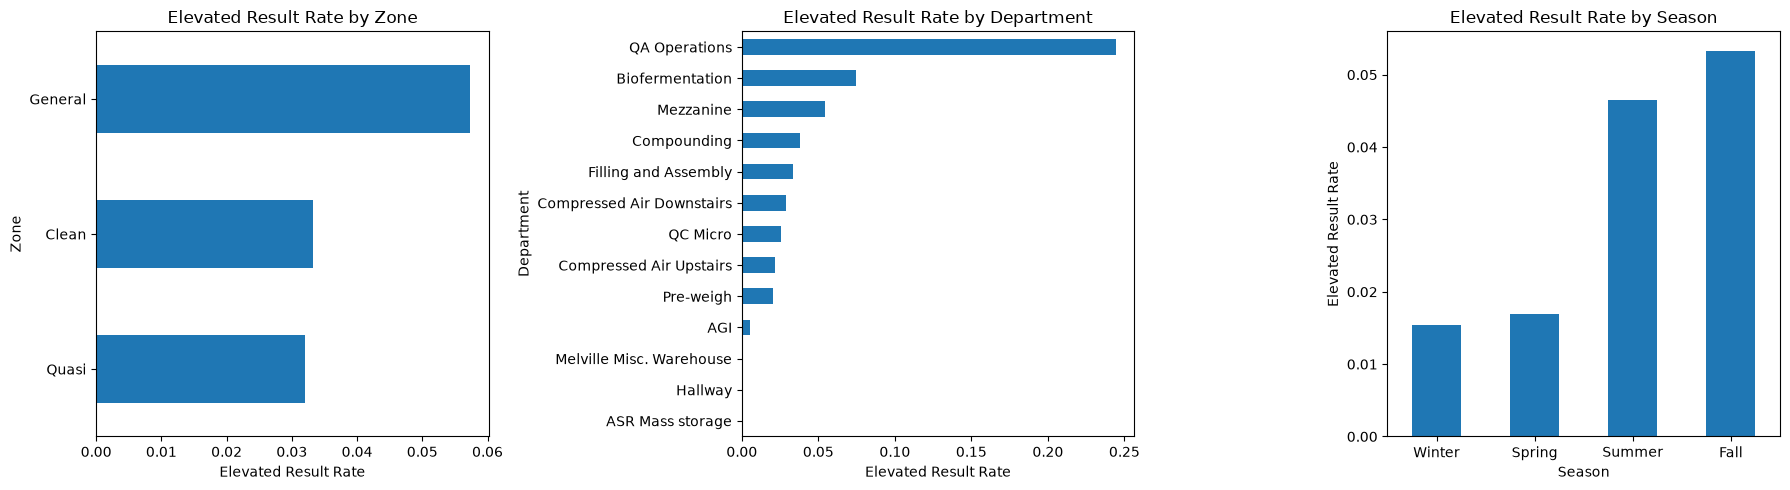

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

zone_summary.sort_values("Elevated_Rate").plot(
    kind="barh",
    y="Elevated_Rate",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Elevated Result Rate by Zone")
axes[0].set_xlabel("Elevated Result Rate")
axes[0].set_ylabel("Zone")


department_summary.sort_values("Elevated_Rate").plot(
    kind="barh",
    y="Elevated_Rate",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Elevated Result Rate by Department")
axes[1].set_xlabel("Elevated Result Rate")
axes[1].set_ylabel("Department")


season_order = ["Winter", "Spring", "Summer", "Fall"]

season_summary.loc[season_order].plot(
    kind="bar",
    y="Elevated_Rate",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Elevated Result Rate by Season")
axes[2].set_xlabel("Season")
axes[2].set_ylabel("Elevated Result Rate")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [50]:
area_top15 = area_summary.head(15).copy()
site_Location_top15 = site_Location_summary.head(15).copy()

area_top15["Elevated_Rate"] = (area_top15["Elevated_Rate"] * 100).round(2)
site_Location_top15["Elevated_Rate"] = (site_Location_top15["Elevated_Rate"] * 100).round(2)

print("Area summary - top 15")
display(area_top15)

print("Site summary - top 15")
display(site_Location_top15)

# This describes the elevated result rate by categorical variables such as zone, department, season, area, and site.


Area summary - top 15


,Sample_Count,Elevated_Count,Elevated_Rate
AreaName,,,
ASR Sampling,89,29,32.58
(BF) Room #3,44,5,11.36
Creams Lab #2,101,10,9.90
Creams Lab #1B,43,4,9.30
East Mezzanine,62,5,8.06
(BF) Micro Lab,41,3,7.32
(BF) Room #1,42,3,7.14
(BF) Room #2,42,3,7.14
Eye Products Lab,48,3,6.25


Site summary - top 15


,Sample_Count,Elevated_Count,Elevated_Rate
Site_Location,,,
Reserve Clean Air - By Drop,7,3,42.86
Inside East end - Room Air,47,18,38.30
Inside West end - Room Air,42,11,26.19
By K40 - Near Kettle,16,4,25.00
By K1B - Near Kettle,16,3,18.75
Air Compressor Tanks - By Drop,6,1,16.67
By K MU-02 - Near Kettle,15,2,13.33
By K16 - Near Kettle,15,2,13.33
By K41 - Near Kettle,15,2,13.33


### Stratified train/test split


In [51]:
X = df[features].copy()
y = df["Elevated_Result"].copy()

# Treat Year as categorical
X["Year"] = X["Year"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Positive class in training set:", round(y_train.mean() * 100, 2), "%")
print("Positive class in test set:", round(y_test.mean() * 100, 2), "%")


Training observations: 8424
Testing observations: 2107
Positive class in training set: 3.41 %
Positive class in test set: 3.42 %


### Pipeline preprocessing



In [ ]:
preprocessor = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), features)])

logistic_model = Pipeline([("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# only 1 was correctly predicted!



Logistic Regression Results
Accuracy: 0.9663
Precision: 1.0
Recall: 0.0139
F1 Score: 0.0274
Average Precision: 0.1619

Confusion Matrix:
[[2035    0]
 [  71    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2035
           1       1.00      0.01      0.03        72

    accuracy                           0.97      2107
   macro avg       0.98      0.51      0.51      2107
weighted avg       0.97      0.97      0.95      2107



### Thoughts on Logistic Regression
The standard logistic regression model achieved an accuracy of 96.63%, exceeding the 70% threshold specified in the alternative hypothesis. Therefore, the alternative hypothesis was supported according to the predefined criterion. However, the confusion matrix showed that the model correctly identified only 1 of 72 elevated results, producing a recall of 1.39%. Because approximately 96.6% of observations were in the acceptable class, a model predicting every observation as acceptable would achieve nearly the same accuracy. Therefore, although the logistic regression model satisfied the formal accuracy criterion, its default predictions were not practically useful for identifying elevated environmental monitoring results.

In [58]:
balanced_logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

balanced_logistic.fit(X_train, y_train)

balanced_pred = balanced_logistic.predict(X_test)
balanced_prob = balanced_logistic.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, balanced_pred), 4))
print("Precision:", round(precision_score(y_test, balanced_pred), 4))
print("Recall:", round(recall_score(y_test, balanced_pred), 4))
print("F1 Score:", round(f1_score(y_test, balanced_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, balanced_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

print("\nClassification Report:")
print(classification_report(y_test, balanced_pred))

Balanced Logistic Regression Results
Accuracy: 0.7513
Precision: 0.0815
Recall: 0.6111
F1 Score: 0.1438
Average Precision: 0.151

Confusion Matrix:
[[1539  496]
 [  28   44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      2035
           1       0.08      0.61      0.14        72

    accuracy                           0.75      2107
   macro avg       0.53      0.68      0.50      2107
weighted avg       0.95      0.75      0.83      2107



### Thoughts on Balanced logistic regression

The balanced logistic regression model achieved an accuracy of 75.13%, with a recall of 61.11% for elevated results. Compared with the standard logistic regression model, the balanced model identified substantially more Alert/Action cases, correctly classifying 44 of 72 elevated samples. However, this improvement in recall came at the cost of 496 false-positive predictions and a precision of only 8.15%. These results demonstrate the tradeoff between detecting more elevated results and increasing the number of acceptable samples incorrectly flagged for follow-up.

In [60]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred), 4))
print("Average Precision:", round(average_precision_score(y_test, rf_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.8083
Precision: 0.0871
Recall: 0.4861
F1 Score: 0.1477
Average Precision: 0.1094

Confusion Matrix:
[[1668  367]
 [  37   35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      2035
           1       0.09      0.49      0.15        72

    accuracy                           0.81      2107
   macro avg       0.53      0.65      0.52      2107
weighted avg       0.95      0.81      0.87      2107



### Thoughts on Random Forest Model

Random Forest Interpretation: The Random Forest model achieved 80.83% accuracy and identified 48.61% of elevated results. Although its recall was lower than the balanced logistic regression, it achieved the highest F1 score (14.77%) among the three models, indicating a slightly better balance between precision and recall.

In [61]:
# Comparing all three models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, balanced_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, rf_pred)
    ],
    "Average Precision": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, balanced_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,Average Precision
0,Logistic Regression,0.9663,1.0000,0.0139,0.0274,0.1619
1,Balanced Logistic Regression,0.7513,0.0815,0.6111,0.1438,0.1510
2,Random Forest,0.8083,0.0871,0.4861,0.1477,0.1094


### comparison of the three models

The standard logistic regression achieved the highest overall accuracy at 96.63%; however, its recall was only 1.39%, indicating that it failed to identify nearly all elevated results. The balanced logistic regression substantially improved recall to 61.11%, although this reduced accuracy and precision. The Random Forest achieved the highest F1 score of 14.77% but detected fewer elevated results than the balanced logistic regression. Because identifying elevated results is more important than maximizing overall accuracy in this application, the balanced logistic regression provided the most useful recall among the tested models.

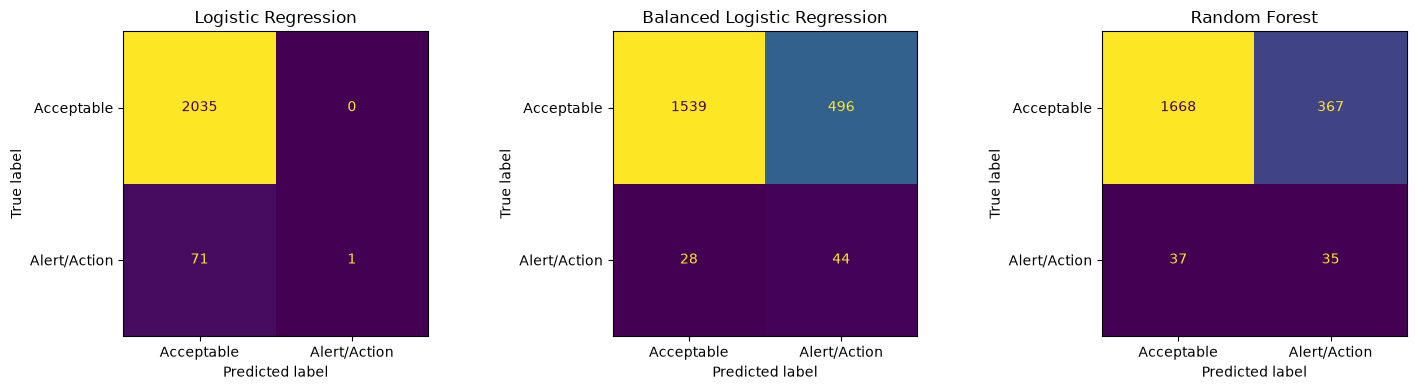

In [67]:
# Confusion Matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, balanced_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[1], colorbar=False)
axes[1].set_title("Balanced Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Acceptable", "Alert/Action"], ax=axes[2], colorbar=False)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrices show that standard logistic regression rarely predicted the elevated class, identifying only 1 of 72 elevated samples. The balanced logistic regression identified the greatest number of elevated samples, while the Random Forest provided a middle ground between elevated result detection and overall accuracy.

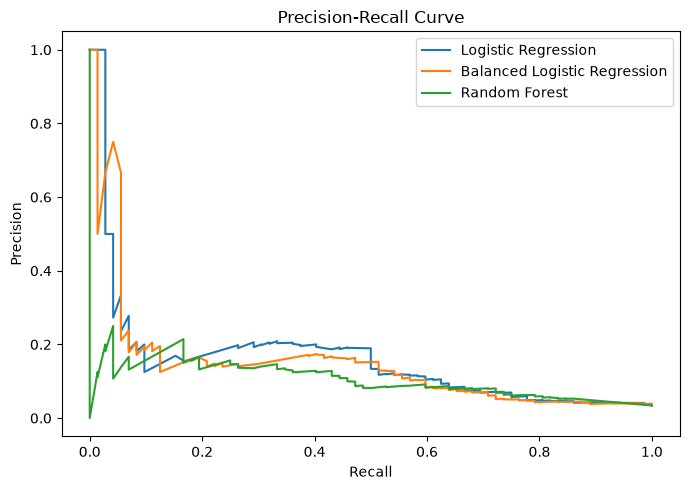

In [68]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, y_prob)
bal_precision, bal_recall, _ = precision_recall_curve(y_test, balanced_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(bal_recall, bal_precision, label="Balanced Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

### Precision Recall Curve Interpretation: 

All three models had difficulty distinguishing elevated results from acceptable results. Precision decreased as recall increased, demonstrating the tradeoff between identifying more Alert/Action results and generating additional false positives. Overall, the relatively low precision across the curves reflects the difficulty of predicting the minority elevated-result class.

In [ ]:
# Logistic regression coefficients

feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = logistic_model.named_steps["model"].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Odds_Ratio"] = np.exp(coefficient_table["Coefficient"])

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_table["Feature"] = (
    coefficient_table["Feature"]
    .str.replace("categorical__", "", regex=False)
)

display(coefficient_table.head(15).round(3))
display(coefficient_table.tail(15).round(3))

,Feature,Coefficient,Odds_Ratio
279,Site_Location_R02 - Filling Room,1.258,3.518
239,Site_Location_LFH 895 - HEPA Hood,1.232,3.427
173,Site_Location_By K51 - Near Kettle,1.212,3.359
137,Site_Location_By K1B - Near Kettle,1.192,3.295
31,AreaName_ASR Sampling,1.174,3.235
283,Site_Location_R03 - Filling Room,1.168,3.216
328,Site_Location_R28 - Air Nozzle,1.154,3.172
11,DepartmentName_QA Operations,1.139,3.124
133,Site_Location_By K16 - Near Kettle,1.129,3.093
275,Site_Location_R01 - Filling Room,1.036,2.818


,Feature,Coefficient,Odds_Ratio
298,Site_Location_R07 - Filling Room,-0.622,0.537
313,Site_Location_R11 - Staging,-0.635,0.530
387,Season_Spring,-0.671,0.511
331,Site_Location_R28 - Staging,-0.706,0.493
292,Site_Location_R05 - Staging,-0.709,0.492
389,Season_Winter,-0.710,0.492
215,Site_Location_Center of Room - Center of Room,-0.728,0.483
37,AreaName_Creams Lab #4,-0.735,0.480
19,AreaName_2nd Floor Hallway,-0.851,0.427
282,Site_Location_R03 - Assembly,-0.902,0.406


### Logistic Regression Coefficient Interpretation: 

The strongest positive coefficients were associated with several specific site-location combinations, including filling-room, HEPA hood, and near-kettle sampling locations. Positive coefficients indicate that these categories were associated with a higher predicted probability of an Alert/Action result. Negative coefficients indicate categories associated with a lower predicted probability. Because the predictors are categorical and some location variables are hierarchical, these coefficients should be interpreted as model associations rather than causal effects.

In [73]:
results_percent = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score", "Average Precision"]:
    results_percent[column] = (results_percent[column] * 100).round(2)

display(results_percent)

,Model,Accuracy,Precision,Recall,F1 Score,Average Precision
0,Logistic Regression,96.63,100.00,1.39,2.74,16.19
1,Balanced Logistic Regression,75.13,8.15,61.11,14.38,15.10
2,Random Forest,80.83,8.71,48.61,14.77,10.94


### Model Comparison: 

The standard logistic regression achieved the highest accuracy at 96.63%, but its recall of 1.39% showed that it identified almost none of the elevated results. The balanced logistic regression achieved the highest recall at 61.11%, while the Random Forest achieved the highest F1 score at 14.77%. For identifying elevated environmental monitoring results, the balanced logistic regression provided the strongest sensitivity, although its low precision indicates that many acceptable samples were also flagged.


### Hypothesis Result: 

The standard logistic regression achieved 96.63% accuracy on the held-out test data, exceeding the predefined 70% threshold. Therefore, the alternative hypothesis was supported. However, because the dataset was highly imbalanced and the standard logistic regression detected only 1 of 72 elevated test samples, accuracy alone did not indicate useful predictive performance.

